In [1]:
import pandas as pd
import numpy as np

np.random.seed(91827365)

In [2]:
import numpy as np
import pandas as pd

days = 130
base_nap = 2  # 2 hour
base_night_sleep = 10.0  # 10 hours
df = pd.DataFrame({'day': pd.date_range(start='2025-05-28', periods=days)})

# df = pd.DataFrame({'day': np.arange(1, days+1)})


df = pd.DataFrame({
    "day": pd.date_range("2025-05-15", periods=days)
})

# Default probability: 10% missed nap
df["miss_prob"] = 0.10

# Override probabilities during berry season
berry_mask = (df["day"] >= "2025-07-01") & (df["day"] <= "2025-08-31")
df.loc[berry_mask, "miss_prob"] = 0.00

# Generate nap durations
df["nap_duration"] = df.apply(
    lambda row: base_nap if np.random.rand() > row["miss_prob"] else 0,
    axis=1
)

df.head(20)

df['nap_duration'] = df['nap_duration'] * np.random.normal(1, 0.05, size=days) * 60 

# 2. Generate night sleep with rebound
df['overnight_sleep'] = base_night_sleep * np.random.normal(1, 0.01, size = days)
for i in range(days):
    if df.loc[i, 'nap_duration'] < 1:  # missed nap
        rebound = np.random.uniform(0.5, 1.0)  # extra night sleep
        df.loc[i, 'overnight_sleep'] += rebound
df['overnight_sleep'] = df['overnight_sleep'] * 60
# 3. Optional: STL residual = overnight_sleep - expected baseline
df['sleep_residual'] = df['overnight_sleep'] - base_night_sleep


In [3]:
# Columns to normalize
cols = ['nap_duration', 'overnight_sleep']

# df-max normalization
df = df.copy()
for col in cols:
    df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# df[[ 'nap_duration_norm', 'overnight_sleep_norm']]

In [4]:
df

,day,miss_prob,nap_duration,overnight_sleep,sleep_residual,nap_duration_norm,overnight_sleep_norm
0,2025-05-15,0.1,121.567097,591.604184,581.604184,0.902817,0.055246
1,2025-05-16,0.1,125.259751,598.374407,588.374407,0.930241,0.144941
2,2025-05-17,0.1,0.000000,643.176863,633.176863,0.000000,0.738500
3,2025-05-18,0.1,127.963944,609.531453,599.531453,0.950324,0.292753
4,2025-05-19,0.1,115.867343,593.778877,583.778877,0.860488,0.084057
...,...,...,...,...,...,...,...
125,2025-09-17,0.1,124.154139,591.214806,581.214806,0.922030,0.050088
126,2025-09-18,0.1,115.215387,603.340935,593.340935,0.855647,0.210739
127,2025-09-19,0.1,128.029792,594.579423,584.579423,0.950813,0.094663
128,2025-09-20,0.1,121.653507,605.709022,595.709022,0.903459,0.242112


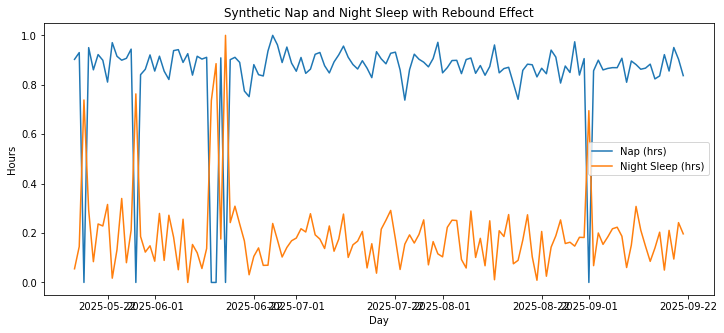

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['day'], df['nap_duration_norm'], label='Nap (hrs)')
plt.plot(df['day'], df['overnight_sleep_norm'], label='Night Sleep (hrs)')
# plt.axhline(base_night_sleep, color='gray', linestyle='--', alpha=0.5)
# for i, nap in enumerate(df['nap_duration']):
#     if nap < 1:
#         plt.axvline(df['day'][i], color='red', linestyle='--', alpha=0.7)
plt.title("Synthetic Nap and Night Sleep with Rebound Effect")
plt.xlabel("Day")
plt.ylabel("Hours")
plt.legend(loc = 'center right')
plt.show()


In [6]:
df['nap_norm'] = (df['nap_duration'] - df['nap_duration'].min()) / (df['nap_duration'].max() - df['nap_duration'].min())
df['sleep_norm'] = (df['overnight_sleep'] - df['overnight_sleep'].min()) / (df['overnight_sleep'].max() - df['overnight_sleep'].min())


In [7]:
# # Parameters
# days = 120
# base_bedtime = 19.5 # 7:30 PM in 24h format
# base_wake = 6.5      # 6:30 AM
# base_nap = 120    # minutes
# base_wakings = 3
# base_waking_duration = 5  # minutes

In [8]:
# # Generate daily dataframe
# df = pd.DataFrame({'day': pd.date_range(start='2025-05-28', periods=days)})
# # Simulate nap duration (sometimes missed)
# df['nap_duration'] = np.random.choice([base_nap, 0], size=days, p=[0.95, 0.05])

# # add some noise to nap duration
# noise = np.random.normal(loc=1.0, scale=0.01, size=len(df['nap_duration']))
# df['nap_duration'] = df['nap_duration'] * noise

In [9]:
# # initialize columns for bed/wake time, night wakings, avg waking duration
# df['bedtime'] = base_bedtime
# df['wake_time'] = base_wake
# df['night_wakings'] = base_wakings
# df['avg_waking_duration'] = base_waking_duration

In [10]:
# df['nap_duration'].mean()

In [11]:
# missed = df[df['nap_duration'] < 0.05]

In [12]:
# # Sloop over days to implement sleep logic
# for i in range(days):
#     # If nap is missed, adjust bedtime earlier by 20-40 min (0.33-0.67 hr)
#     if df.loc[i, 'nap_duration'] == 0:
#         df.loc[i, 'bedtime'] = base_bedtime - np.random.uniform(0.33, 0.67)
#         # Increase night wakings by 1-2
#         df.loc[i, 'night_wakings'] = base_wakings + np.random.randint(5, 10)
#         # Optionally increase avg waking duration by 5-15 min
#         df.loc[i, 'avg_waking_duration'] = base_waking_duration + np.random.randint(5, 15)
#         df.loc[i+1, 'wake_time'] = base_wake + np.random.uniform(-0.7, 0.1)
#         df.loc[i+1, 'nap_duration'] += np.random.uniform(0.7, 8)
#     else:
#         # Reset to base bedtime and wakings if nap was taken
#         df.loc[i, 'bedtime'] = base_bedtime + np.random.normal(loc = 0, scale = 0.1)
#         df.loc[i, 'night_wakings'] = base_wakings
#         df.loc[i, 'avg_waking_duration'] = base_waking_duration
#     df.loc[i, 'wake_time'] = df.loc[i, 'wake_time'] * np.random.normal(loc = 1, scale = 0.01)
#     # Wake time adjustment: ±15-20 min (0.25-0.33 hr) randomly
#     # if df.loc[i, 'nap_duration'] == 0:
#     #     df.loc[i, 'bedtime'] -=
    

#     # Step 5: Rebound nap effect for next day (if nap missed today)
#     # if i < days - 1 and df.loc[i, 'nap_duration'] == 0:
#           # 10-15 min increase

In [13]:
# df

In [14]:
# df['lost_sleep'] = df['night_wakings'] * df['avg_waking_duration']

In [15]:
# df

In [16]:
# df['overnight_sleep'] = (df['wake_time'] - df['bedtime'] + 24) % 24
# df['overnight_sleep_minutes'] = df['overnight_sleep'] * 60
# # df['overnight_sleep_minutes'] = df['overnight_sleep_minutes'] - (df['night_wakings'] * df['avg_waking_duration'])

In [17]:
# df['overnight_sleep_minutes'] = df['overnight_sleep_minutes'] - df['lost_sleep']

In [18]:
# df = df[['day', 'wake_time', 'nap_duration', 'bedtime', 'night_wakings','avg_waking_duration','overnight_sleep','overnight_sleep_minutes']]

In [19]:
df

,day,miss_prob,nap_duration,overnight_sleep,sleep_residual,nap_duration_norm,overnight_sleep_norm,nap_norm,sleep_norm
0,2025-05-15,0.1,121.567097,591.604184,581.604184,0.902817,0.055246,0.902817,0.055246
1,2025-05-16,0.1,125.259751,598.374407,588.374407,0.930241,0.144941,0.930241,0.144941
2,2025-05-17,0.1,0.000000,643.176863,633.176863,0.000000,0.738500,0.000000,0.738500
3,2025-05-18,0.1,127.963944,609.531453,599.531453,0.950324,0.292753,0.950324,0.292753
4,2025-05-19,0.1,115.867343,593.778877,583.778877,0.860488,0.084057,0.860488,0.084057
...,...,...,...,...,...,...,...,...,...
125,2025-09-17,0.1,124.154139,591.214806,581.214806,0.922030,0.050088,0.922030,0.050088
126,2025-09-18,0.1,115.215387,603.340935,593.340935,0.855647,0.210739,0.855647,0.210739
127,2025-09-19,0.1,128.029792,594.579423,584.579423,0.950813,0.094663,0.950813,0.094663
128,2025-09-20,0.1,121.653507,605.709022,595.709022,0.903459,0.242112,0.903459,0.242112


In [20]:
# # Nighttime sleep hours
# # Base sleep minus penalty for missed nap (lagged effect)
# df['overnight_sleep'] = (df['wake_time'] - df['bedtime'] + 24) % 24
# df['overnight_sleep_minutes'] = df['overnight_sleep'] * 60
# df['overnight_sleep_minutes'] = df['overnight_sleep_minutes'] - (df['night_wakings'] * df['avg_waking_duration'])
# # Introduce lagged disruptions
# # for i in range(days):
# #     if df.loc[i, 'nap_duration'] == 0:
# #         df.loc[i, 'overnight_sleep'] -= np.random.uniform(0.5, 1.5)  # same night
# #         if i + 1 < days:
# #             df.loc[i+1, 'overnight_sleep'] -= np.random.uniform(0.2, 0.8)  # next night

# # Night wakings and avg waking duration
# # df['night_wakings'] = base_wakings + ((df['nap_duration']==0).astype(int)*np.random.randint(1,3, size=days))
# # df['avg_waking_duration'] = base_waking_duration + ((df['nap_duration']==0).astype(int)*np.random.randint(5,15, size=days))

# # Clip values to realistic ranges
# df['overnight_sleep'] = df['overnight_sleep'].clip(lower=6, upper=12)
# df['night_wakings'] = df['night_wakings'].clip(lower=0, upper=10)
# df['avg_waking_duration'] = df['avg_waking_duration'].clip(lower=5, upper=30)

# df

In [21]:
# # Columns to normalize
# cols = ['nap_duration', 'overnight_sleep']

# # df-max normalization
# df = df.copy()
# for col in cols:
#     df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# df[[ 'nap_duration_norm', 'overnight_sleep_norm']]

In [22]:
import matplotlib.pyplot as plt

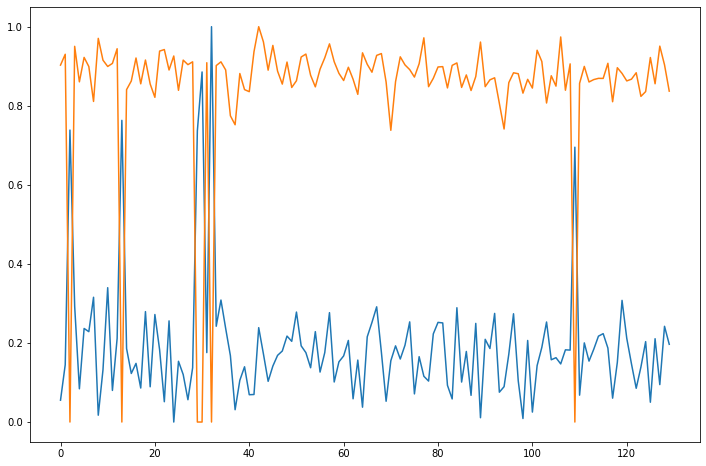

In [23]:
plt.figure(figsize = (12,8))
plt.plot(df['sleep_norm'])
plt.plot(df['nap_norm'])
# plt.yscale('log')

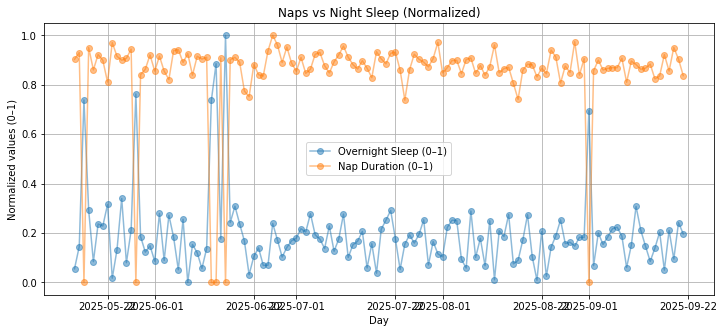

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df['day'], df['sleep_norm'], label='Overnight Sleep (0–1)', marker = 'o', alpha = 0.5)
plt.plot(df['day'], df['nap_norm'], label='Nap Duration (0–1)', marker='o', alpha = 0.5)
plt.ylabel('Normalized values (0–1)')
plt.xlabel('Day')
plt.title('Naps vs Night Sleep (Normalized)')
plt.legend()
plt.grid(True)
plt.show()


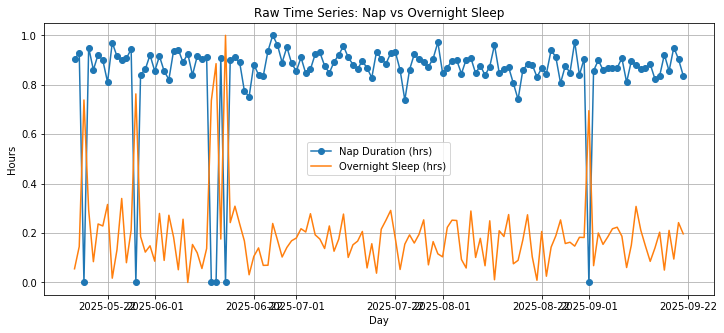

In [25]:
plt.figure(figsize=(12,5))
plt.plot(df['day'], df['nap_norm'], label='Nap Duration (hrs)', marker='o')
plt.plot(df['day'], df['sleep_norm'], label='Overnight Sleep (hrs)')
plt.title("Raw Time Series: Nap vs Overnight Sleep")
plt.xlabel("Day")
plt.ylabel("Hours")
plt.grid(True)
plt.legend()
plt.show()


In [26]:
# plt.figure(figsize=(12,5))
# plt.plot(df['day'], df['nap_norm'], label='Nap (0–1)', marker='o')
# plt.plot(df['day'], df['sleep_norm'], label='Overnight Sleep (0–1)')
# # plt.plot(df['day'], df['nap_norm'], label='Nap (0–1)')
# plt.axvspan('2025-07-01', '2025-08-31', color='purple', alpha=0.1, label='Berry Season')
# plt.title("Normalized Time Series (Comparable Scale)")
# plt.xlabel("Day")
# plt.ylabel("Normalized Value")
# plt.grid(True)
# plt.legend()
# plt.show()


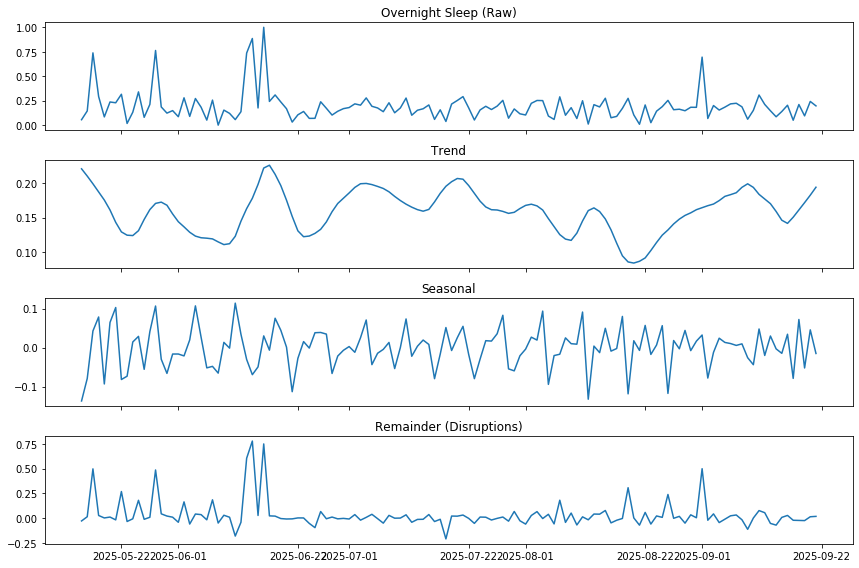

In [27]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['sleep_norm'], period=7, robust=True).fit()

df['sleep_trend'] = stl.trend
df['sleep_seasonal'] = stl.seasonal
df['sleep_resid'] = stl.resid

fig, ax = plt.subplots(4, 1, figsize=(12,8), sharex=True)

ax[0].plot(df['day'], df['sleep_norm'])
ax[0].set_title("Overnight Sleep (Raw)")

ax[1].plot(df['day'], df['sleep_trend'])
ax[1].set_title("Trend")

ax[2].plot(df['day'], df['sleep_seasonal'])
ax[2].set_title("Seasonal")

ax[3].plot(df['day'], df['sleep_resid'])
ax[3].set_title("Remainder (Disruptions)")

plt.tight_layout()
plt.show()


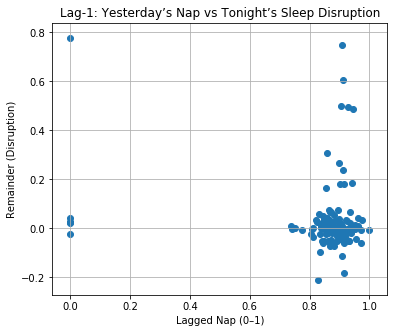

              lag_nap  sleep_resid
lag_nap      1.000000    -0.133987
sleep_resid -0.133987     1.000000


In [28]:
df['lag_nap'] = df['nap_norm'].shift(1)

plt.figure(figsize=(6,5))
plt.scatter(df['lag_nap'], df['sleep_resid'])
plt.title("Lag-1: Yesterday’s Nap vs Tonight’s Sleep Disruption")
plt.xlabel("Lagged Nap (0–1)")
plt.ylabel("Remainder (Disruption)")
plt.grid(True)
plt.show()

print(df[['lag_nap','sleep_resid']].corr())


In [29]:
missed = df[df['nap_duration'] < 0.05]


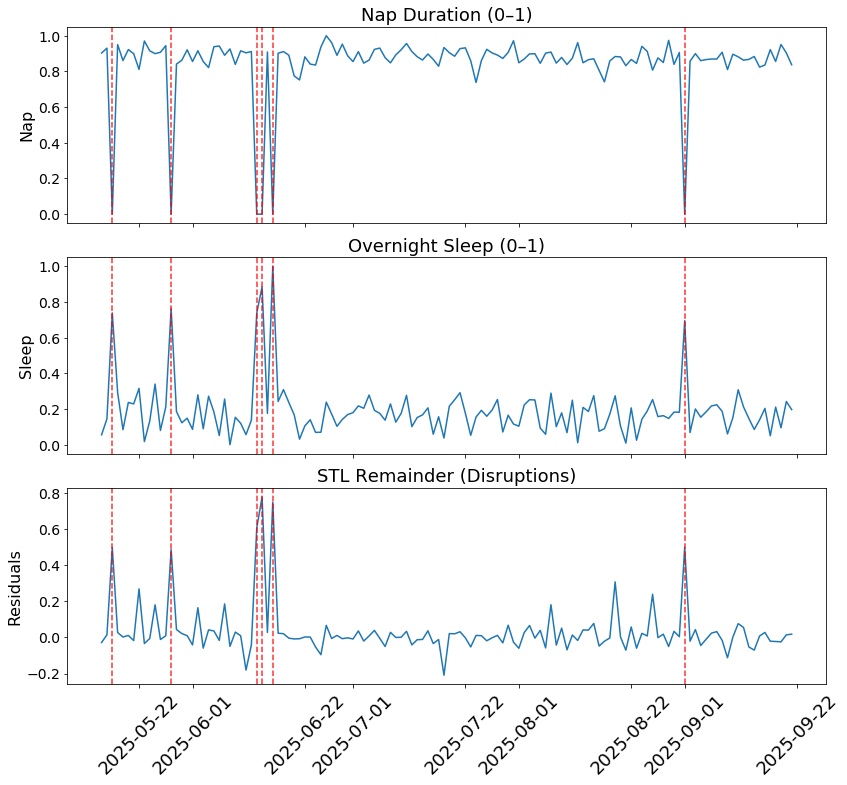

In [52]:
fig, ax = plt.subplots(3, 1, figsize=(12,10), sharex=True)

# --- Subplot 1: Nap Duration ---
ax[0].plot(df['day'], df['nap_norm'])
ax[0].set_title("Nap Duration (0–1)", fontsize=18)
ax[0].set_ylabel("Nap", fontsize=16)
ax[0].tick_params(axis='both', labelsize=14)

# --- Subplot 2: Overnight Sleep ---
ax[1].plot(df['day'], df['sleep_norm'])
ax[1].set_title("Overnight Sleep (0–1)", fontsize=18)
ax[1].set_ylabel("Sleep", fontsize=16)
ax[1].tick_params(axis='both', labelsize=14)

# --- Subplot 3: STL Residuals ---
ax[2].plot(df['day'], df['sleep_resid'])
ax[2].set_title("STL Remainder (Disruptions)", fontsize=18)
ax[2].set_ylabel("Residuals", fontsize=16)
ax[2].tick_params(axis='both', labelsize=14)

# --- Missed Nap Markers ---
for d in missed['day']:
    for i in range(3):
        ax[i].axvline(d, color='red', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.savefig("missed_nap_stl.png", dpi=300)
plt.xticks(fontsize = 18, rotation = 45)
plt.show()


In [31]:
from statsmodels.tsa.seasonal import STL

series = df['sleep_norm']

stl = STL(series, period=7)  # weekly seasonality is reasonable for toddlers
res = stl.fit()

df['trend'] = res.trend
df['seasonal'] = res.seasonal
df['residual'] = res.resid


In [32]:
df

,day,miss_prob,nap_duration,overnight_sleep,sleep_residual,nap_duration_norm,overnight_sleep_norm,nap_norm,sleep_norm,sleep_trend,sleep_seasonal,sleep_resid,lag_nap,trend,seasonal,residual
0,2025-05-15,0.1,121.567097,591.604184,581.604184,0.902817,0.055246,0.902817,0.055246,0.220586,-0.137078,-0.028263,NaN,0.328899,-0.107989,-0.165664
1,2025-05-16,0.1,125.259751,598.374407,588.374407,0.930241,0.144941,0.930241,0.144941,0.210087,-0.079307,0.014161,0.902817,0.314977,-0.212751,0.042715
2,2025-05-17,0.1,0.000000,643.176863,633.176863,0.000000,0.738500,0.000000,0.738500,0.198895,0.042778,0.496827,0.930241,0.299815,0.203614,0.235071
3,2025-05-18,0.1,127.963944,609.531453,599.531453,0.950324,0.292753,0.950324,0.292753,0.187239,0.078708,0.026807,0.000000,0.285719,0.075379,-0.068345
4,2025-05-19,0.1,115.867343,593.778877,583.778877,0.860488,0.084057,0.860488,0.084057,0.175394,-0.093335,0.001998,0.950324,0.271961,-0.220255,0.032351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2025-09-17,0.1,124.154139,591.214806,581.214806,0.922030,0.050088,0.922030,0.050088,0.150549,-0.079053,-0.021408,0.835850,0.147001,-0.076051,-0.020862
126,2025-09-18,0.1,115.215387,603.340935,593.340935,0.855647,0.210739,0.855647,0.210739,0.161085,0.072282,-0.022627,0.922030,0.156640,0.089626,-0.035527
127,2025-09-19,0.1,128.029792,594.579423,584.579423,0.950813,0.094663,0.950813,0.094663,0.171617,-0.052253,-0.024701,0.855647,0.165717,-0.039081,-0.031973
128,2025-09-20,0.1,121.653507,605.709022,595.709022,0.903459,0.242112,0.903459,0.242112,0.182436,0.045641,0.014036,0.950813,0.174569,0.055297,0.012246


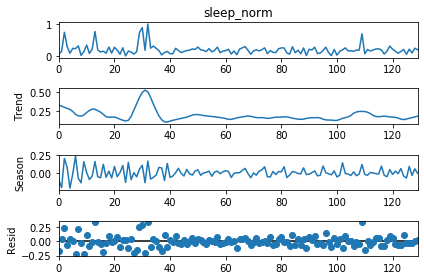

In [33]:
res.plot()
plt.show()


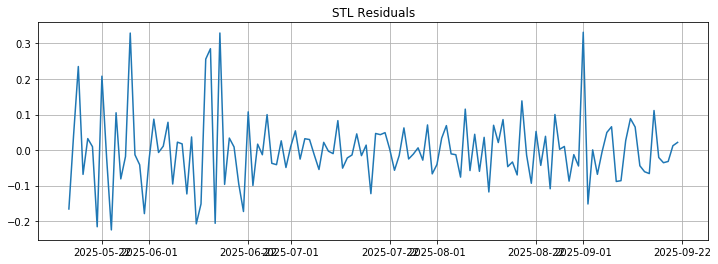

In [34]:
plt.figure(figsize=(12,4))
plt.plot(df['day'], df['residual'])
plt.title("STL Residuals")
plt.grid(True)
plt.show()


/home/simonhans/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:1406: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


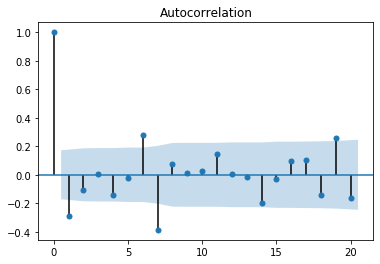

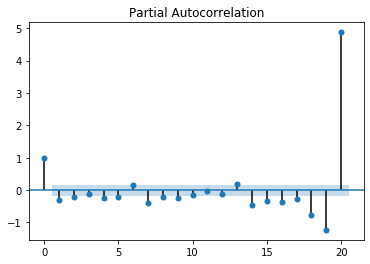

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['residual'], lags=20)
plot_pacf(df['residual'], lags=20)
plt.show()


In [36]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['residual'], order=(1,0,1))
result = model.fit()

print(result.summary())


                               SARIMAX Results                                
Dep. Variable:               residual   No. Observations:                  130
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 139.934
Date:                Wed, 26 Nov 2025   AIC                           -271.868
Time:                        12:37:08   BIC                           -260.398
Sample:                             0   HQIC                          -267.207
                                - 130                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.496e-05      0.000     -0.135      0.893      -0.001       0.001
ar.L1          0.3441      0.080      4.282      0.000       0.187       0.502
ma.L1         -0.9999     29.893     -0.033      0.9

In [37]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(result.resid, lags=[10], return_df=True)


,lb_stat,lb_pvalue
10,28.881896,0.001302


In [38]:
df['missed_nap'] = (df['nap_duration'] < 0.05).astype(int)

model = ARIMA(df['residual'], order=(1,0,1), exog=df['missed_nap'])
result = model.fit()

print(result.summary())


                               SARIMAX Results                                
Dep. Variable:               residual   No. Observations:                  130
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 158.845
Date:                Wed, 26 Nov 2025   AIC                           -307.689
Time:                        12:37:08   BIC                           -293.352
Sample:                             0   HQIC                          -301.863
                                - 130                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0107      0.004     -2.390      0.017      -0.019      -0.002
missed_nap     0.2317      0.032      7.193      0.000       0.169       0.295
ar.L1          0.0491      0.244      0.201      0.8

/home/simonhans/anaconda3/lib/python3.7/site-packages/statsmodels/base/model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


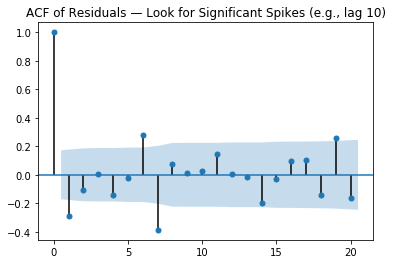

In [39]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['residual'], lags=20)
plt.title("ACF of Residuals — Look for Significant Spikes (e.g., lag 10)")
plt.show()


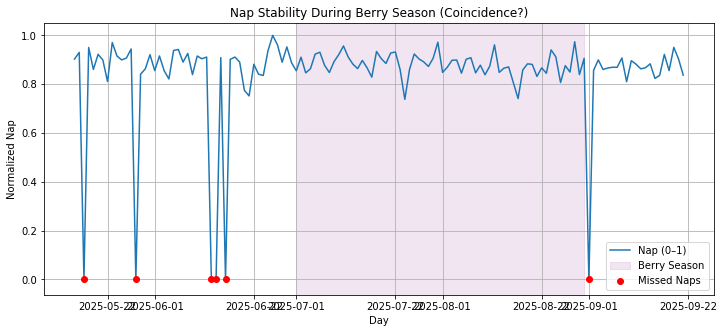

In [40]:
plt.figure(figsize=(12,5))
plt.plot(df['day'], df['nap_norm'], label='Nap (0–1)')
plt.axvspan('2025-07-01', '2025-08-31', color='purple', alpha=0.1, label='Berry Season')

missed = df[df['nap_duration'] < 0.05]
plt.scatter(missed['day'], [0]*len(missed), color='red', label='Missed Naps', zorder=5)

plt.title("Nap Stability During Berry Season (Coincidence?)")
plt.xlabel("Day")
plt.ylabel("Normalized Nap")
plt.legend()
plt.grid(True)
plt.show()


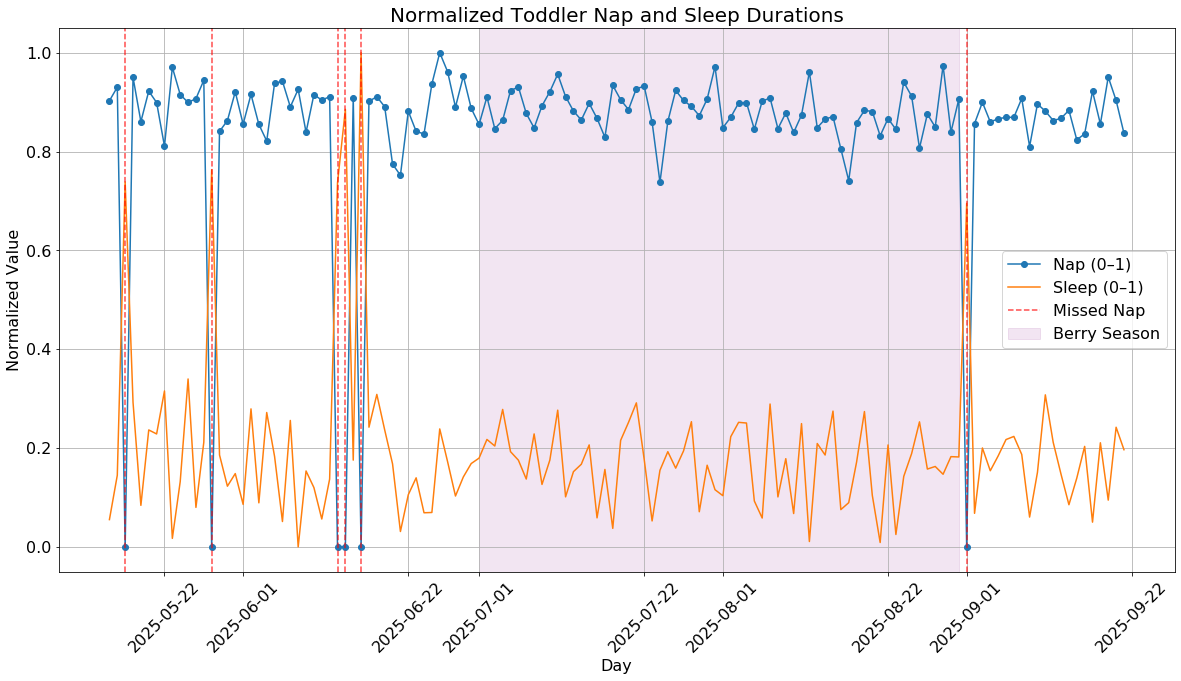

In [56]:
plt.figure(figsize=(20,10))
plt.plot(df['day'], df['nap_norm'], label='Nap (0–1)', marker='o')
plt.plot(df['day'], df['sleep_norm'], label='Sleep (0–1)')
plt.axvspan('2025-07-01', '2025-08-31', color='purple', alpha=0.1, label='Berry Season')

missed = df[df['nap_duration'] < 0.05]
first = True
for d in missed['day']:
    if first:
        plt.axvline(d, color='red', linestyle='--', alpha=0.7, label='Missed Nap')
        first = False
    else:
        plt.axvline(d, color='red', linestyle='--', alpha=0.7)

plt.title("Normalized Toddler Nap and Sleep Durations", fontsize = 20)
plt.xlabel("Day", fontsize = 16)
plt.ylabel("Normalized Value", fontsize = 16)
plt.grid(True)
plt.xticks(size = 16, rotation = 45)
plt.yticks(size = 16)
plt.legend(fontsize = 16)
plt.savefig('missed_naps.png')
plt.show()
